In [21]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [22]:
df = pd.read_csv('titanic.csv')
print('Train:', df.shape)

Train: (891, 15)


In [23]:
df.describe

<bound method NDFrame.describe of      survived  pclass     sex   age  sibsp  parch     fare embarked   class  \
0           0       3    male  22.0      1      0   7.2500        S   Third   
1           1       1  female  38.0      1      0  71.2833        C   First   
2           1       3  female  26.0      0      0   7.9250        S   Third   
3           1       1  female  35.0      1      0  53.1000        S   First   
4           0       3    male  35.0      0      0   8.0500        S   Third   
..        ...     ...     ...   ...    ...    ...      ...      ...     ...   
886         0       2    male  27.0      0      0  13.0000        S  Second   
887         1       1  female  19.0      0      0  30.0000        S   First   
888         0       3  female   NaN      1      2  23.4500        S   Third   
889         1       1    male  26.0      0      0  30.0000        C   First   
890         0       3    male  32.0      0      0   7.7500        Q   Third   

       who  adult

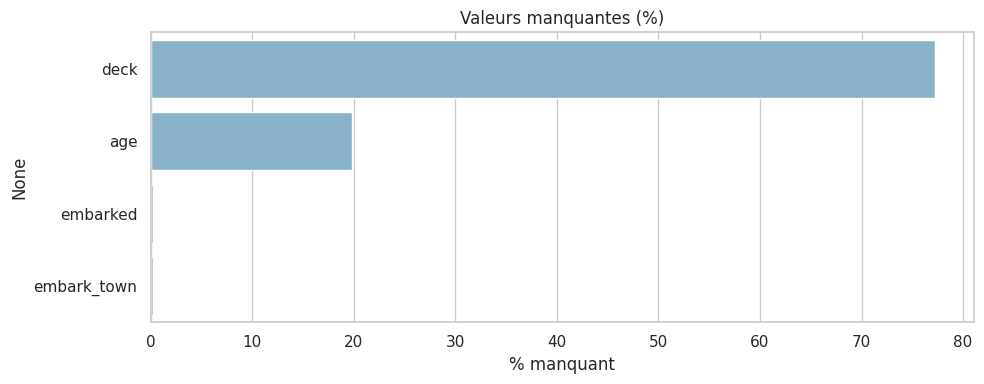

In [24]:
# Valeurs manquantes
missing_pct = df.isna().mean().sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(x=missing_pct.values * 100, y=missing_pct.index, ax=ax, color='#7FB3D5')
ax.set_title('Valeurs manquantes (%)')
ax.set_xlabel('% manquant')
plt.tight_layout()
plt.show()

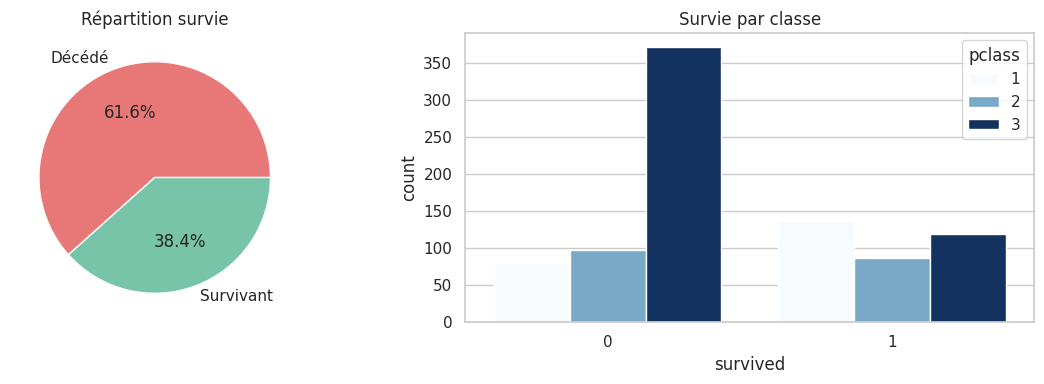

In [25]:
# Distribution de la cible
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['survived'].value_counts().plot.pie(
    labels=['Décédé', 'Survivant'], autopct='%1.1f%%',
    colors=['#E87878', '#78C4A8'], ax=axes[0]
)
axes[0].set_title('Répartition survie')

sns.countplot(x='survived', hue='pclass', data=df,
              palette='Blues', ax=axes[1])
axes[1].set_title('Survie par classe')
plt.tight_layout()
plt.show()

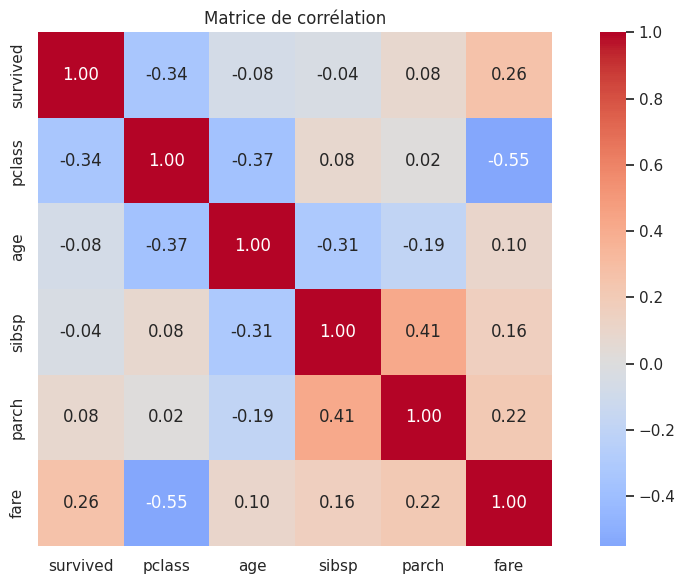

In [26]:
# Corrélation numérique
fig, ax = plt.subplots(figsize=(10, 6))
num_cols = ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=ax, square=True)
ax.set_title('Matrice de corrélation')
plt.tight_layout()
plt.show()

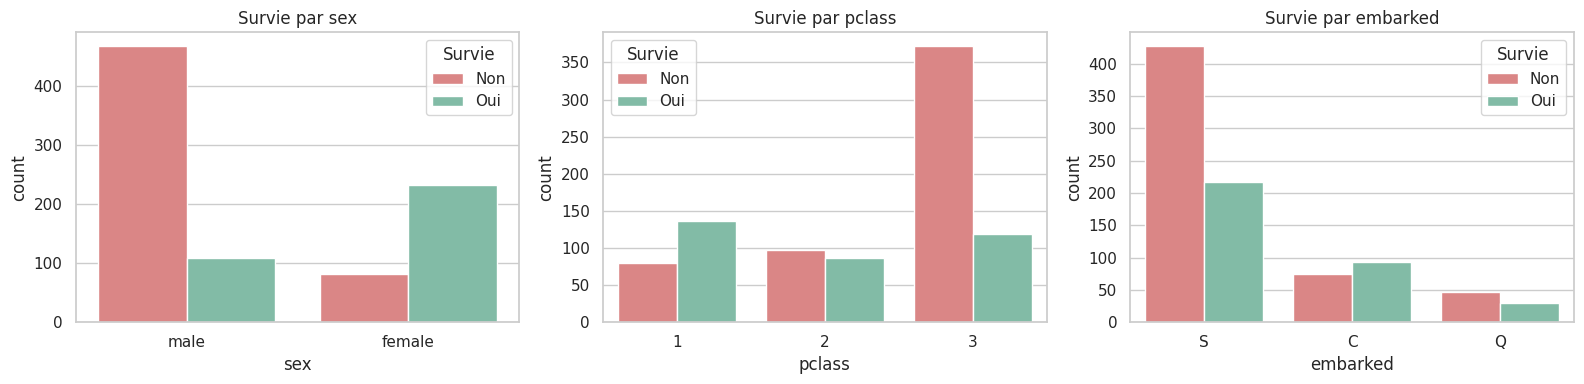

In [27]:
# Variables catégorielles vs survie
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ['sex', 'pclass', 'embarked']):
    sns.countplot(x=col, hue='survived', data=df,
                  palette={0: '#E87878', 1: '#78C4A8'}, ax=ax)
    ax.set_title(f'Survie par {col}')
    ax.legend(labels=['Non', 'Oui'], title='Survie')
plt.tight_layout()
plt.show()

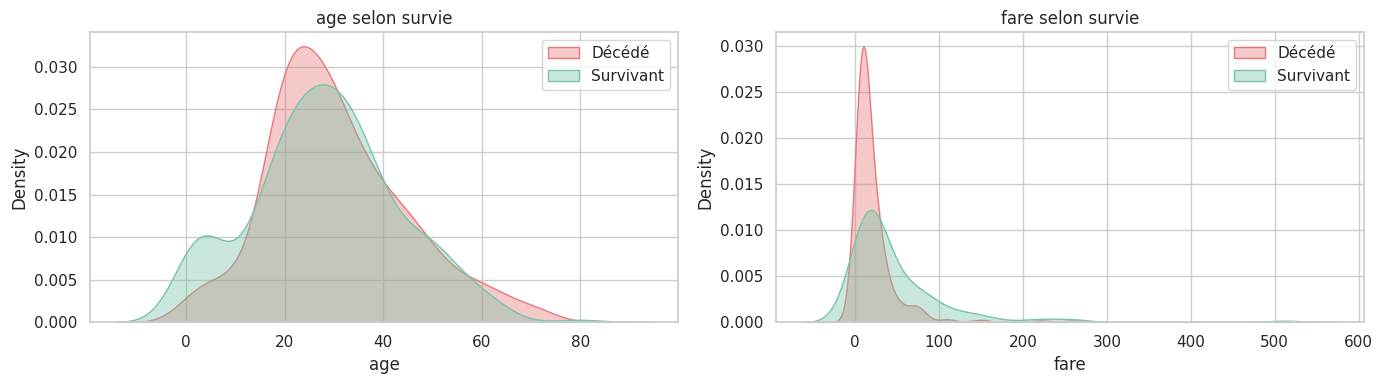

In [28]:
# Distribution Age et Fare selon survie
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col in zip(axes, ['age', 'fare']):
    for val, color, label in [(0, '#E87878', 'Décédé'), (1, '#78C4A8', 'Survivant')]:
        sns.kdeplot(df[df['survived'] == val][col].dropna(),
                    ax=ax, color=color, label=label, fill=True, alpha=0.4)
    ax.set_title(f'{col} selon survie')
    ax.legend()
plt.tight_layout()
plt.show()